# Step 2 — Exploratory Data Analysis

## Objective

This notebook explores the factors associated with total delivery time, `Time_taken(min)`, before modeling.

The analysis covers:

- the structure and quality of the cleaned dataset;
- descriptive statistics for numerical features;
- category frequencies, including `Vehicle_condition`;
- the distribution of the target;
- relationships between the target and each feature;
- correlations between numerical features;
- the features most strongly associated with delivery time;
- the decisions carried forward to feature engineering.

No derived features are created during cleaning. GPS coordinates and date/time columns are explored here in their raw form. Transformations such as `Distance_km`, `Order_Hour`, `Pickup_Hour`, `Order_DayOfWeek`, `Order_Month`, `Order_Day`, `Is_Weekend`, and `Preparation_Time_min` are left for the feature engineering notebook.

EDA is used to understand the data. It should not rely on information that would be unavailable at prediction time, and unusual observations should not be removed automatically just because they are atypical.


In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

sns.set_theme(style="whitegrid")

TARGET = "Time_taken(min)"
PROJECT_ROOT = Path(f"{Path.cwd()}/02_eda.ipynb").resolve().parents[1]
DATA_PATH = PROJECT_ROOT / "data" / "food-delivery-cleaned.csv"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    path = FIGURES_DIR / name
    plt.savefig(path, dpi=150, bbox_inches="tight")
    return path


## 1. Load the cleaned dataset

The EDA starts from the dataset produced by the cleaning step.

Cleaning decisions carried forward:

- `ID` and `Delivery_person_ID` were removed because they are identifiers.
- `Vehicle_condition` was kept and treated as a nominal categorical feature; no ordering between values 0 and 3 is assumed.
- `Time_Order_picked` was kept unchanged.
- Missing values in `Time_Orderd` were imputed during cleaning using `Time_Order_picked` and a temporary median preparation time.

No imputation flag or derived feature was kept at this stage. Distance, preparation time, and extracted date/time features are created only during feature engineering.


In [5]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found at {DATA_PATH}. Run 01_cleaning.ipynb first."
    )

df = pd.read_csv(DATA_PATH)

df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")
df["Time_Orderd"] = pd.to_datetime(df["Time_Orderd"], errors="coerce")
df["Time_Order_picked"] = pd.to_datetime(df["Time_Order_picked"], errors="coerce")

df["Vehicle_condition"] = df["Vehicle_condition"].astype("category")

print(f"Shape: {df.shape}")
display(df.head())


Shape: (41953, 18)


,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.000,4.900,22.745,75.892,22.765,75.912,2022-03-19,1900-01-01 11:30:00,1900-01-01 11:45:00,Sunny,High,2,Snack,motorcycle,0.000,No,Urban,24
1,34.000,4.500,12.913,77.683,13.043,77.813,2022-03-25,1900-01-01 19:45:00,1900-01-01 19:50:00,Stormy,Jam,2,Snack,scooter,1.000,No,Metropolitian,33
2,23.000,4.400,12.914,77.678,12.924,77.688,2022-03-19,1900-01-01 08:30:00,1900-01-01 08:45:00,Sandstorms,Low,0,Drinks,motorcycle,1.000,No,Urban,26
3,38.000,4.700,11.004,76.976,11.054,77.026,2022-04-05,1900-01-01 18:00:00,1900-01-01 18:10:00,Sunny,Medium,0,Buffet,motorcycle,1.000,No,Metropolitian,21
4,32.000,4.600,12.973,80.250,13.013,80.290,2022-03-26,1900-01-01 13:30:00,1900-01-01 13:45:00,Cloudy,High,1,Snack,scooter,1.000,No,Metropolitian,30


## 2. General structure check

Check the dataset dimensions, data types, missing values, duplicates, and target statistics to confirm that the cleaning step was applied correctly.


In [6]:
print("Dimensions:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing"))

print("\nComplete duplicates:", df.duplicated().sum())

print("\nTarget statistics:")
display(df[TARGET].describe())

print("\nRemaining missing values in Time_Orderd:")
print(df["Time_Orderd"].isna().sum())

Dimensions: (41953, 18)

Columns:
['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']

Data types:


,dtype
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,datetime64[us]
Time_Orderd,datetime64[us]
Time_Order_picked,datetime64[us]
Weatherconditions,str



Missing values:


,missing
Delivery_person_Age,0
Delivery_person_Ratings,0
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,0
Time_Order_picked,0
Weatherconditions,0



Complete duplicates: 0

Target statistics:


count   41953.000
mean       26.312
std         9.381
min        10.000
25%        19.000
50%        26.000
75%        32.000
max        54.000
Name: Time_taken(min), dtype: float64


Remaining missing values in Time_Orderd:
0


## 3. Descriptive analysis — numerical features

For numerical features, review the count, mean, median, standard deviation, minimum, and maximum.

The median is useful when a distribution is not perfectly symmetric.


In [7]:
numeric_columns = df.select_dtypes(include=["number"]).columns.tolist()

numeric_descriptive = df[numeric_columns].agg(
    ["count", "mean", "median", "std", "min", "max"]
).T

display(numeric_descriptive)

,count,mean,median,std,min,max
Delivery_person_Age,41953.000,29.574,30.000,5.654,20.000,40.000
Delivery_person_Ratings,41953.000,4.634,4.700,0.326,1.000,5.000
Restaurant_latitude,41953.000,18.911,19.066,5.468,9.957,30.914
Restaurant_longitude,41953.000,76.923,76.618,3.503,72.769,88.433
Delivery_location_latitude,41953.000,18.975,19.123,5.470,9.967,31.054
Delivery_location_longitude,41953.000,76.987,76.664,3.503,72.779,88.563
multiple_deliveries,41953.000,0.751,1.000,0.567,0.000,3.000
Time_taken(min),41953.000,26.312,26.000,9.381,10.000,54.000


## 4. Descriptive analysis — categorical features

For each categorical feature, inspect absolute and relative frequencies to identify dominant categories, rare classes, and representation imbalances that may matter during encoding.

`Vehicle_condition` is included here as a nominal categorical feature rather than an ordered numerical scale.


In [8]:
categorical_columns = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_columns = [
    column for column in categorical_columns
    if column != TARGET
]

for column in categorical_columns:
    print(f"\n### {column}")
    frequency = (
        df[column]
        .value_counts(dropna=False)
        .rename_axis(column)
        .to_frame("count")
    )
    frequency["percentage"] = (
        frequency["count"] / len(df) * 100
    )
    display(frequency)


### Weatherconditions


,count,percentage
Weatherconditions,,
Fog,7581,18.070
Stormy,6974,16.623
Cloudy,6932,16.523
Sandstorms,6906,16.461
Windy,6832,16.285
Sunny,6728,16.037



### Road_traffic_density


,count,percentage
Road_traffic_density,,
Low,14755,35.170
Jam,13043,31.090
Medium,10084,24.036
High,4071,9.704



### Vehicle_condition


...

,count,percentage
Type_of_vehicle,,
motorcycle,24396,58.151
scooter,14029,33.440
electric_scooter,3468,8.266
bicycle,60,0.143



### Festival


,count,percentage
Festival,,
No,41131,98.041
Yes,822,1.959



### City


,count,percentage
City,,
Metropolitian,31411,74.872
Urban,9279,22.118
Unknown,1114,2.655
Semi-Urban,149,0.355


## 5. Distribution of `Time_taken(min)`

Inspect the target before modeling using a histogram, density estimate, boxplot, and summary statistics.

High delivery times are not removed automatically because long deliveries may represent valid operating conditions rather than bad data.


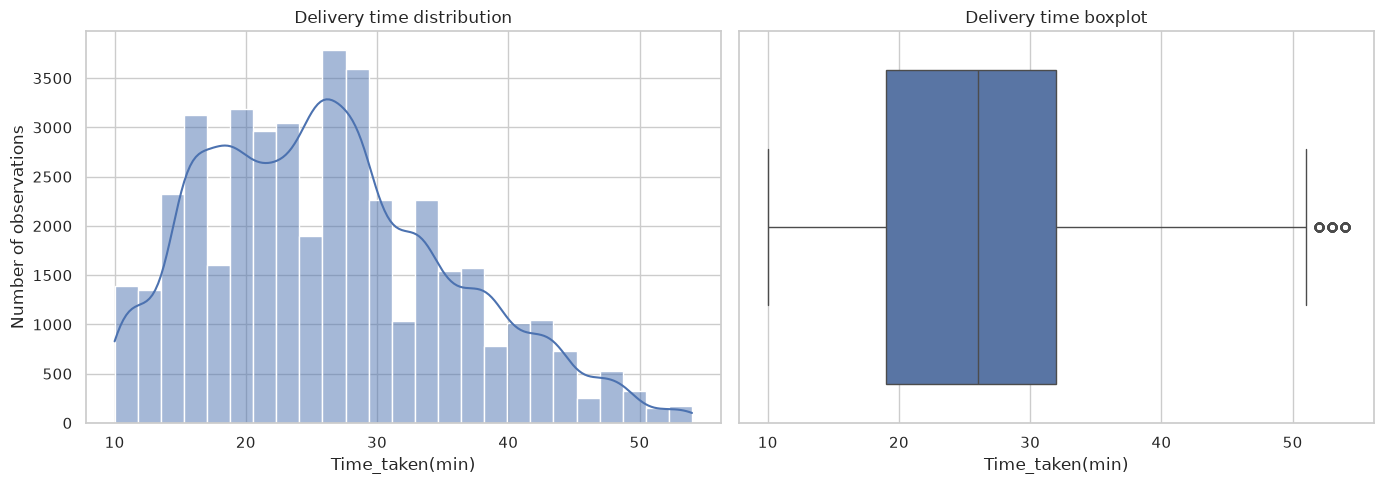

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    df[TARGET],
    kde=True,
    bins=25,
    ax=axes[0],
)
axes[0].set_title("Delivery time distribution")
axes[0].set_xlabel("Time_taken(min)")
axes[0].set_ylabel("Number of observations")

sns.boxplot(
    x=df[TARGET],
    ax=axes[1],
)
axes[1].set_title("Delivery time boxplot")
axes[1].set_xlabel("Time_taken(min)")

plt.tight_layout()
save_fig("target_distribution.png")
plt.show()

## 6. Target vs. numerical features

For each numerical feature, inspect its visual relationship with the target and calculate both Pearson and Spearman correlation.

- **Pearson** measures linear association.
- **Spearman** measures monotonic association and is less dependent on a strictly linear relationship.

GPS coordinates are analyzed in their raw form here. The actual restaurant-to-customer distance is created later during feature engineering.


,pearson,spearman,abs_spearman
multiple_deliveries,0.378,0.330,0.330
Delivery_person_Age,0.295,0.309,0.309
Delivery_person_Ratings,-0.335,-0.287,0.287
Delivery_location_latitude,0.014,0.029,0.029
Delivery_location_longitude,0.010,0.027,0.027
Restaurant_latitude,0.012,0.012,0.012
Restaurant_longitude,0.007,0.005,0.005


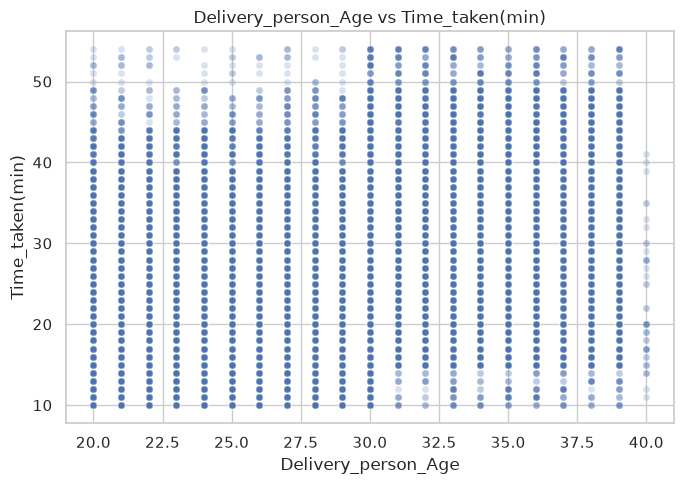

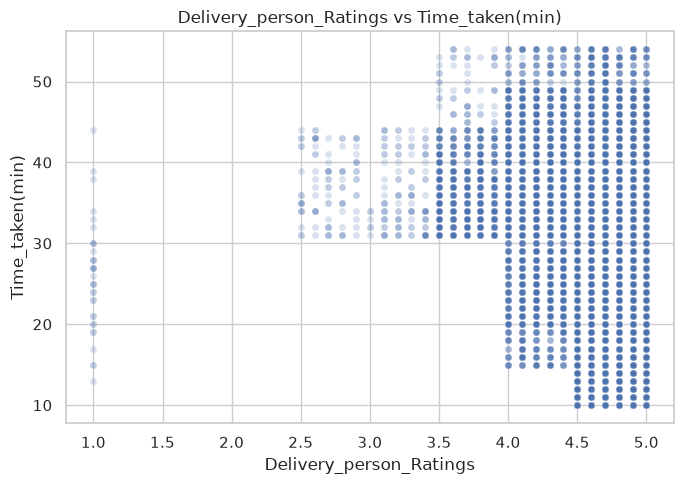

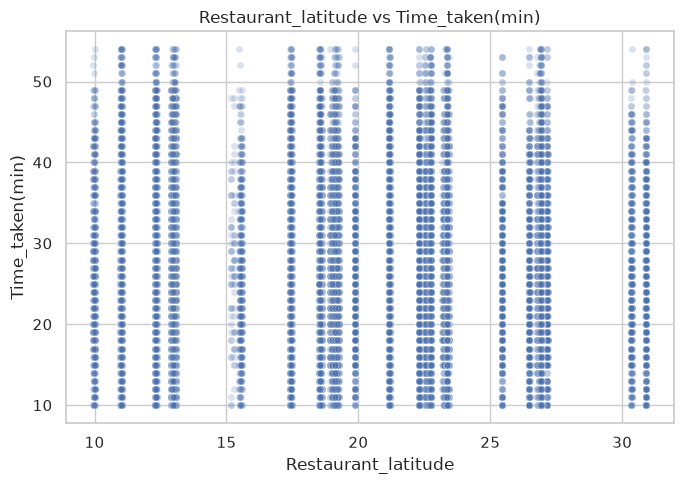

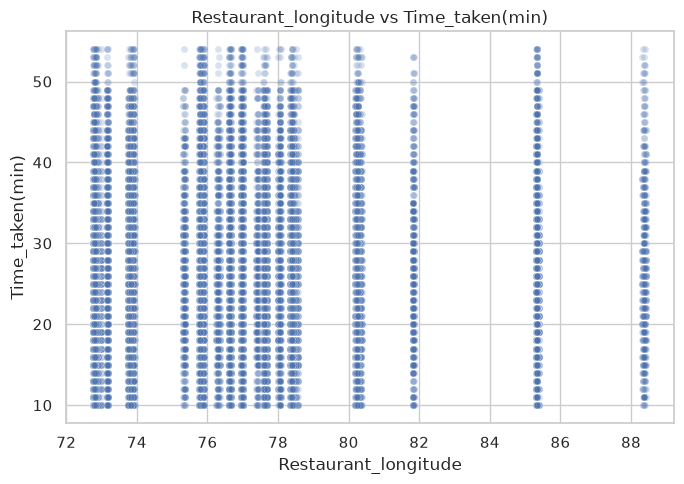

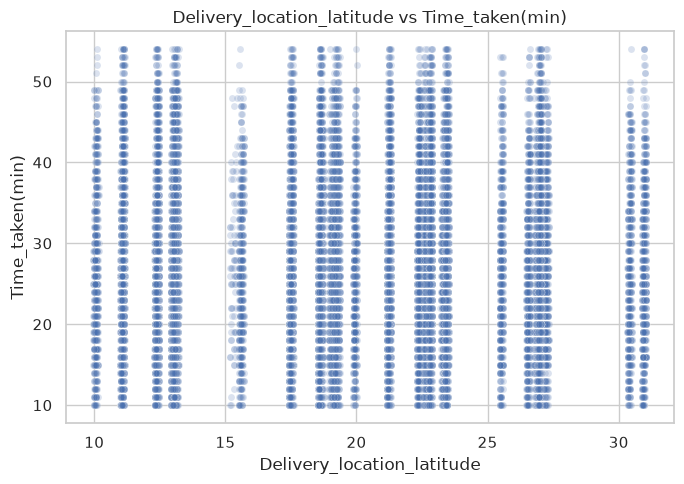

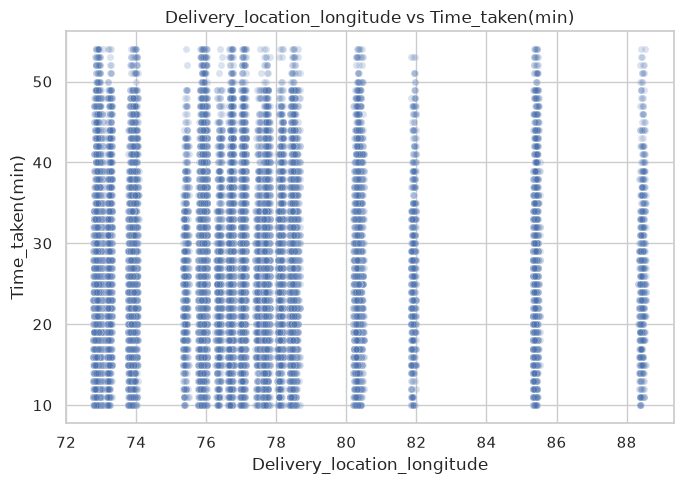

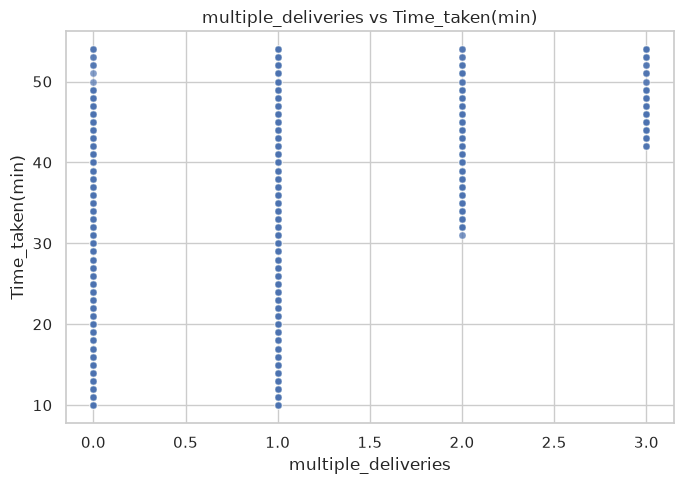

In [10]:
numeric_predictors = [
    column for column in numeric_columns
    if column != TARGET
]

pearson = df[numeric_predictors + [TARGET]].corr(method="pearson")[TARGET].drop(TARGET)
spearman = df[numeric_predictors + [TARGET]].corr(method="spearman")[TARGET].drop(TARGET)

numeric_relationships = pd.DataFrame({
    "pearson": pearson,
    "spearman": spearman,
    "abs_spearman": spearman.abs(),
}).sort_values("abs_spearman", ascending=False)

display(numeric_relationships)

for column in numeric_predictors:
    plt.figure(figsize=(7, 5))
    sns.scatterplot(
        data=df,
        x=column,
        y=TARGET,
        alpha=0.20,
        s=25,
    )
    plt.title(f"{column} vs {TARGET}")
    plt.xlabel(column)
    plt.ylabel(TARGET)
    plt.tight_layout()
    save_fig(f"target_vs_{column}.png")
    plt.show()

## 7. Exploratory time analysis

`Order_Date` and `Time_Orderd` are temporal features and will not be passed directly to a regression model.

For EDA only, temporary features are created for order hour, day of week, month, and weekend status. `Pickup_Hour`, derived from `Time_Order_picked`, is also used for exploration.

These temporary columns are not added to the cleaned dataset.


In [11]:
eda_time = df.copy()

eda_time["Order_Hour"] = eda_time["Time_Orderd"].dt.hour
eda_time["Order_DayOfWeek"] = eda_time["Order_Date"].dt.dayofweek
eda_time["Order_Month"] = eda_time["Order_Date"].dt.month
eda_time["Is_Weekend"] = eda_time["Order_DayOfWeek"].isin([5, 6])

day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

eda_time["Day_Name"] = eda_time["Order_DayOfWeek"].map(day_names)

temporal_hour_summary = (
    eda_time.groupby("Order_Hour", dropna=False)[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

temporal_day_summary = (
    eda_time.groupby(
        "Day_Name",
        dropna=False,
    )[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

temporal_month_summary = (
    eda_time.groupby(
        "Order_Month",
        dropna=False,
    )[TARGET]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

display(temporal_hour_summary)
display(temporal_day_summary)
display(temporal_month_summary)

,Order_Hour,count,mean,median,std
0,0,415,22.229,21.000,7.251
1,8,1749,19.623,19.000,5.613
2,9,1878,19.481,19.000,5.524
3,10,1887,19.484,19.000,5.532
4,11,1865,26.478,27.000,8.317
5,12,860,26.877,27.000,8.736
6,13,748,27.766,27.000,8.686
7,14,756,27.308,27.000,8.238
8,15,831,23.237,23.000,6.949
9,16,676,23.055,24.000,6.895


,Day_Name,count,mean,median,std
0,Friday,6408,26.823,26.000,9.516
1,Monday,5722,26.227,25.000,9.326
2,Saturday,5810,25.973,25.000,9.284
3,Sunday,5736,26.457,25.500,9.390
4,Thursday,5841,25.284,25.000,9.013
5,Tuesday,5884,25.435,25.000,9.089
6,Wednesday,6552,27.762,27.000,9.730


,Order_Month,count,mean,median,std
0,2,6016,26.517,26.000,9.392
1,3,29972,26.305,26.000,9.399
2,4,5965,26.136,25.000,9.277


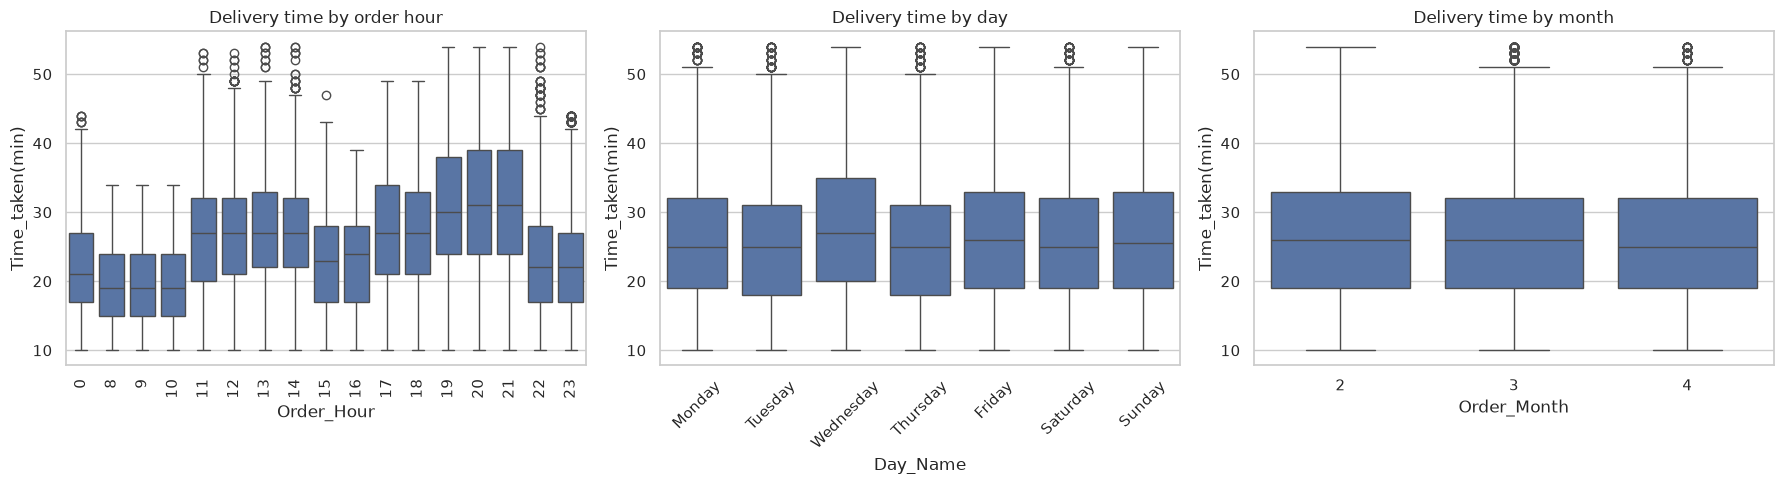

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(
    data=eda_time,
    x="Order_Hour",
    y=TARGET,
    ax=axes[0],
)
axes[0].set_title("Delivery time by order hour")
axes[0].tick_params(axis="x", rotation=90)

sns.boxplot(
    data=eda_time,
    x="Day_Name",
    y=TARGET,
    order=list(day_names.values()),
    ax=axes[1],
)
axes[1].set_title("Delivery time by day")
axes[1].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=eda_time,
    x="Order_Month",
    y=TARGET,
    ax=axes[2],
)
axes[2].set_title("Delivery time by month")

plt.tight_layout()
save_fig("target_temporal_relationships.png")
plt.show()

## 8. Target vs. categorical features

For each categorical feature, compare category size, mean delivery time, median, standard deviation, and the distribution of the target.

Eta-squared is also calculated as a descriptive measure of association between a categorical feature and the numerical target. Higher values indicate larger between-group differences relative to the total target variance; they do not establish causality.

`Vehicle_condition` is included in this comparison with the other categorical features.


,feature,eta_squared,n_unique
0,Road_traffic_density,0.179,4
1,Festival,0.083,2
2,Vehicle_condition,0.080,4
3,City,0.063,4
4,Weatherconditions,0.062,6
5,Type_of_vehicle,0.027,4
6,Type_of_order,0.000,4



### Weatherconditions


,count,mean,median,std
Weatherconditions,,,,
Cloudy,6932,28.926,29.000,10.023
Fog,7581,28.777,28.000,10.098
Windy,6832,26.129,26.000,8.621
Stormy,6974,25.897,26.000,8.488
Sandstorms,6906,25.881,26.000,8.638
Sunny,6728,21.897,20.000,8.358


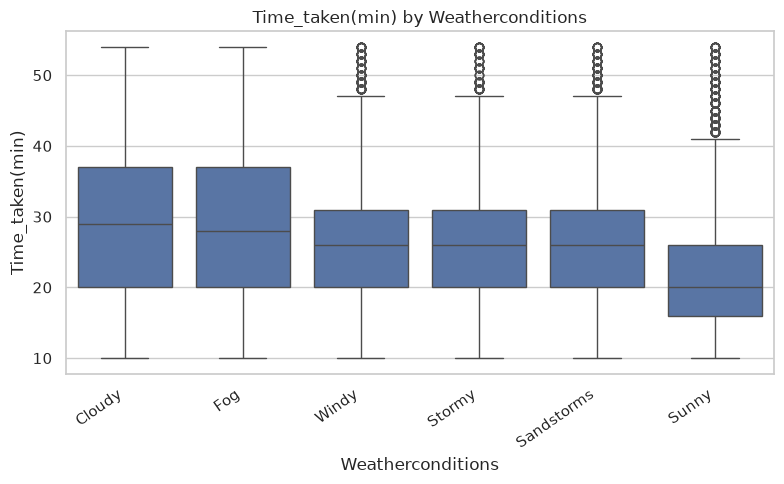


### Road_traffic_density


,count,mean,median,std
Road_traffic_density,,,,
Jam,13043,31.183,31.000,9.937
High,4071,27.226,27.000,8.416
Medium,10084,26.726,27.000,8.526
Low,14755,21.469,21.000,6.995


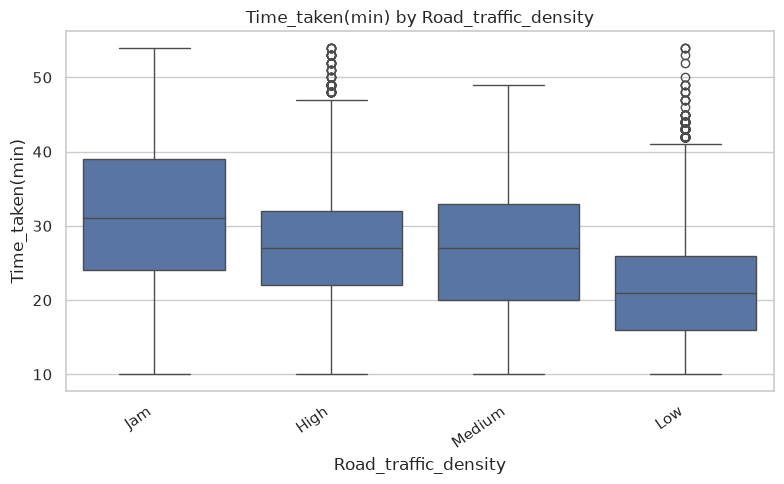


### Vehicle_condition


,count,mean,median,std
Vehicle_condition,,,,
0,13815,30.091,28.000,9.580
3,481,26.231,26.000,9.331
2,13806,24.479,24.000,8.663
1,13851,24.371,24.000,8.708


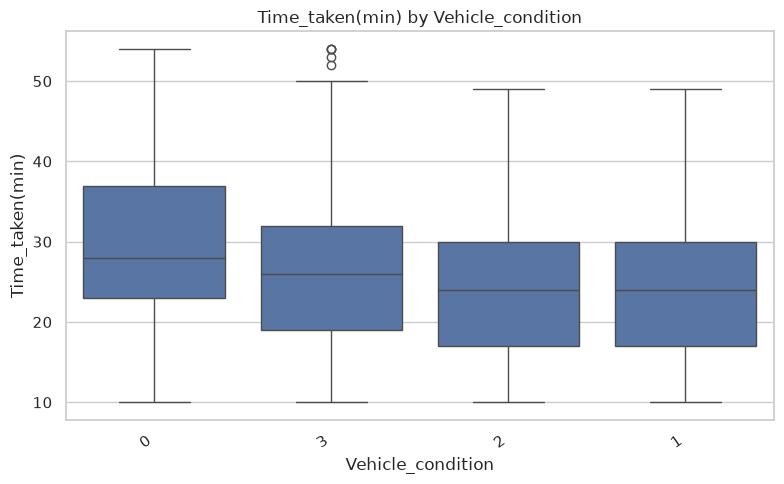


### Type_of_order


,count,mean,median,std
Type_of_order,,,,
Meal,10524,26.487,26.000,9.426
Snack,10616,26.324,26.000,9.418
Buffet,10368,26.240,25.500,9.386
Drinks,10445,26.194,25.000,9.290


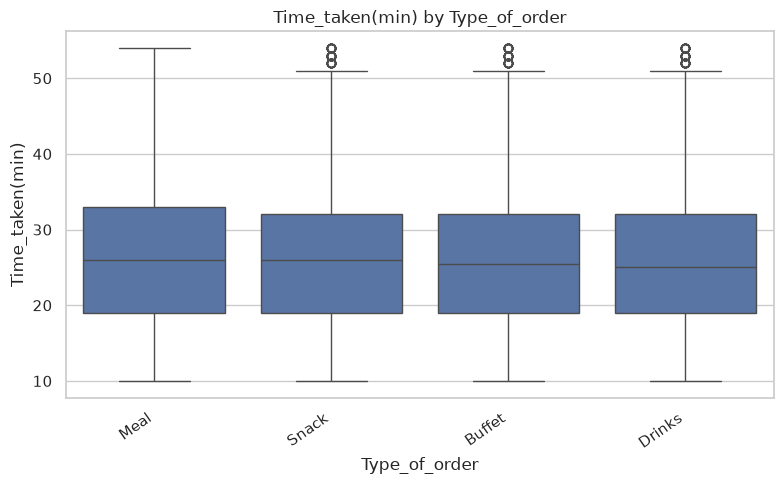


### Type_of_vehicle


,count,mean,median,std
Type_of_vehicle,,,,
motorcycle,24396,27.609,26.000,9.638
bicycle,60,26.417,26.500,8.960
scooter,14029,24.512,24.000,8.707
electric_scooter,3468,24.460,24.000,8.643


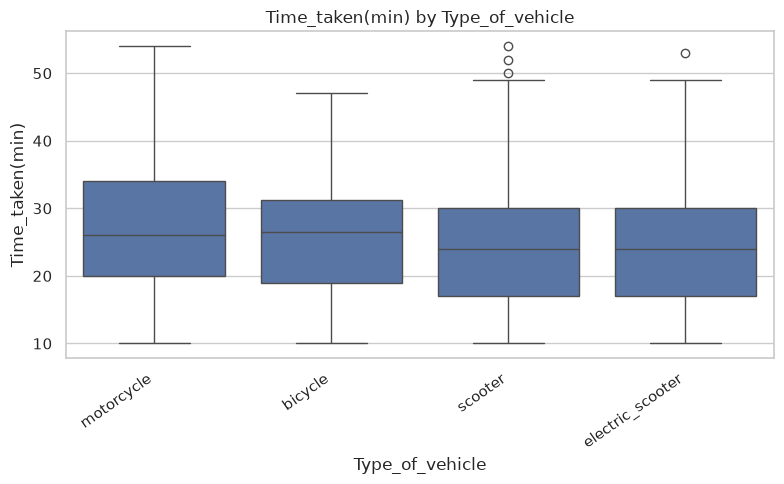


### Festival


,count,mean,median,std
Festival,,,,
Yes,822,45.479,45.000,4.017
No,41131,25.928,25.000,9.052


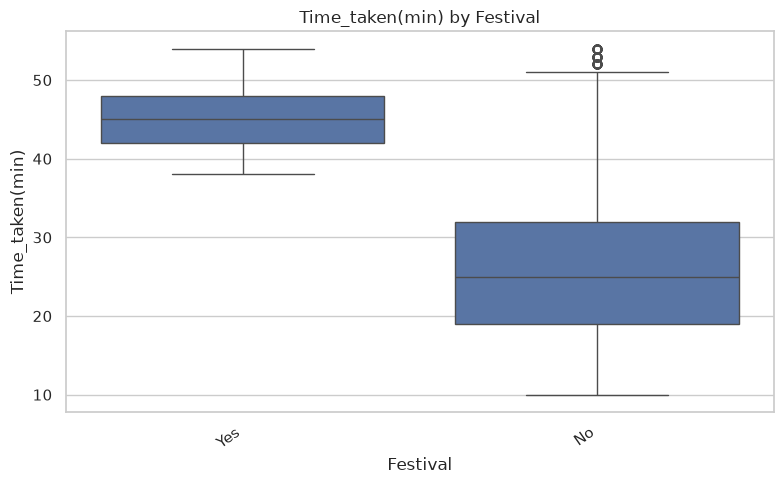


### City


,count,mean,median,std
City,,,,
Semi-Urban,149,49.678,49.000,2.732
Metropolitian,31411,27.321,27.000,9.186
Urban,9279,23.025,22.000,8.870
Unknown,1114,22.092,21.000,8.309


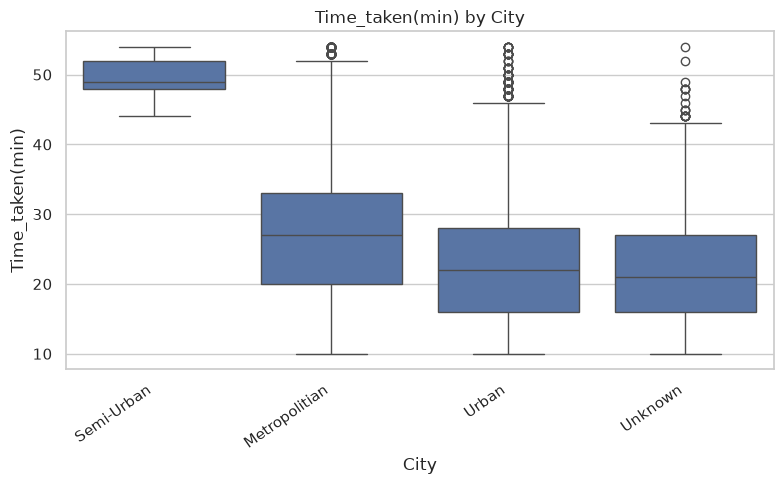

In [13]:
def eta_squared(data, category_column, target_column):
    valid = data[[category_column, target_column]].dropna()
    grand_mean = valid[target_column].mean()

    group_stats = (
        valid.groupby(category_column)[target_column]
        .agg(["count", "mean"])
    )

    between_ss = (
        group_stats["count"]
        * (group_stats["mean"] - grand_mean) ** 2
    ).sum()

    total_ss = (
        (valid[target_column] - grand_mean) ** 2
    ).sum()

    if total_ss == 0:
        return 0.0

    return between_ss / total_ss

categorical_relationships = []

for column in categorical_columns:
    categorical_relationships.append({
        "feature": column,
        "eta_squared": eta_squared(df, column, TARGET),
        "n_unique": df[column].nunique(dropna=False),
    })

categorical_relationships = (
    pd.DataFrame(categorical_relationships)
    .sort_values("eta_squared", ascending=False)
    .reset_index(drop=True)
)

display(categorical_relationships)

for column in categorical_columns:
    summary = (
        df.groupby(column, dropna=False)[TARGET]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )

    print(f"\n### {column}")
    display(summary)

    plt.figure(figsize=(8, 5))
    order = (
        df.groupby(column)[TARGET]
        .mean()
        .sort_values(ascending=False)
        .index
    )

    sns.boxplot(
        data=df,
        x=column,
        y=TARGET,
        order=order,
    )

    plt.title(f"{TARGET} by {column}")
    plt.xticks(rotation=35, ha="right")
    plt.tight_layout()
    save_fig(f"target_vs_{column}.png")
    plt.show()

## 9. Correlation matrix

The Spearman correlation matrix is calculated for numerical features only. It helps identify relationships with the target, strong relationships between predictors, and possible redundancy.

Correlation describes association, not causation.


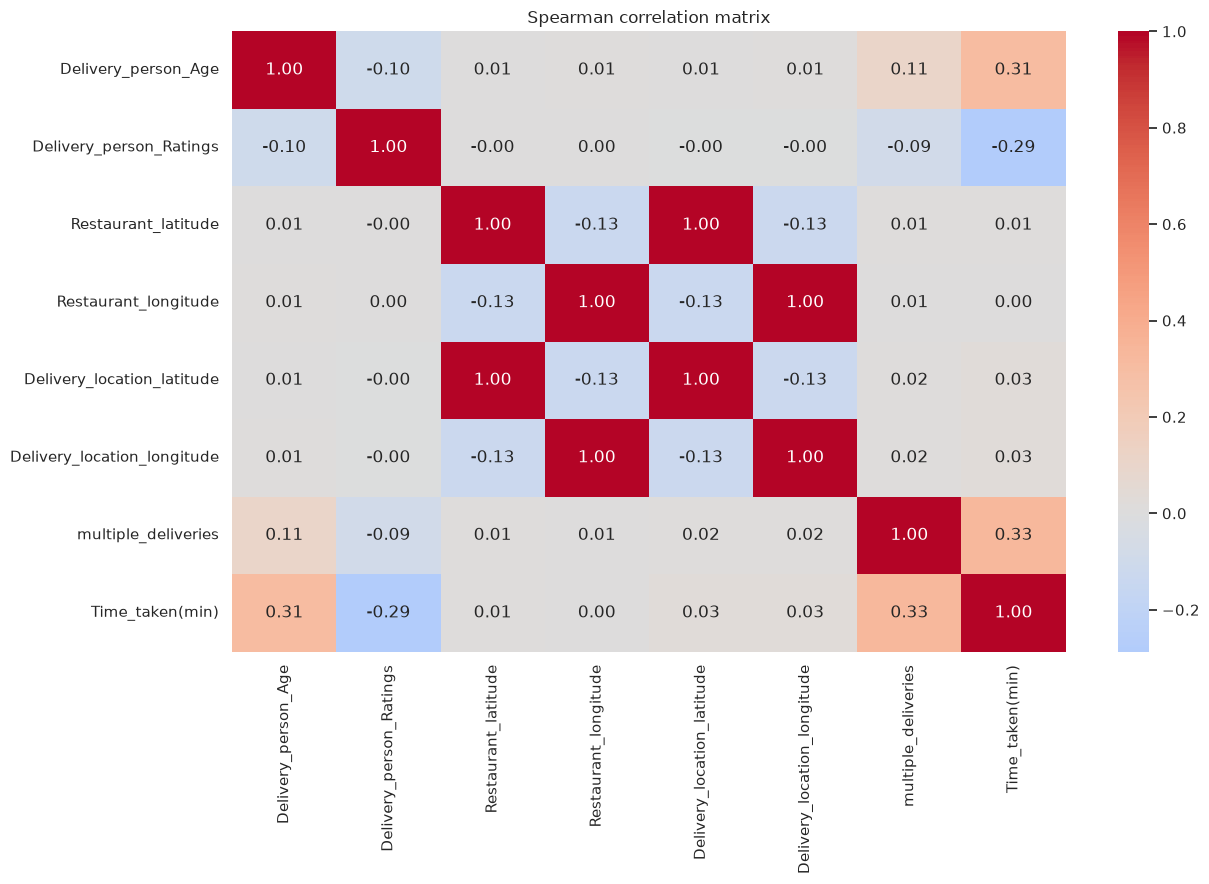

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,multiple_deliveries,Time_taken(min)
Delivery_person_Age,1.000,-0.102,0.006,0.010,0.006,0.010,0.109,0.309
Delivery_person_Ratings,-0.102,1.000,-0.000,0.003,-0.004,-0.002,-0.086,-0.287
Restaurant_latitude,0.006,-0.000,1.000,-0.132,0.997,-0.130,0.011,0.012
Restaurant_longitude,0.010,0.003,-0.132,1.000,-0.133,0.996,0.008,0.005
Delivery_location_latitude,0.006,-0.004,0.997,-0.133,1.000,-0.127,0.017,0.029
Delivery_location_longitude,0.010,-0.002,-0.130,0.996,-0.127,1.000,0.015,0.027
multiple_deliveries,0.109,-0.086,0.011,0.008,0.017,0.015,1.000,0.330
Time_taken(min),0.309,-0.287,0.012,0.005,0.029,0.027,0.330,1.000


In [14]:
correlation_matrix = df[numeric_columns].corr(method="spearman")

plt.figure(figsize=(13, 9))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Spearman correlation matrix")
plt.tight_layout()
save_fig("correlation_matrix_spearman.png")
plt.show()

display(correlation_matrix)

## 10. Features most associated with delivery time

Numerical features are ranked by absolute Spearman correlation, while categorical features are ranked by eta-squared.

These values are exploratory. They help guide feature engineering but do not determine on their own which features should be kept in the final model.


In [15]:
print("Top numerical features by |Spearman|:")
display(
    numeric_relationships[
        ["pearson", "spearman"]
    ].head(10)
)

print("\nTop categorical features by eta-squared:")
display(
    categorical_relationships.head(10)
)

Top numerical features by |Spearman|:


,pearson,spearman
multiple_deliveries,0.378,0.330
Delivery_person_Age,0.295,0.309
Delivery_person_Ratings,-0.335,-0.287
Delivery_location_latitude,0.014,0.029
Delivery_location_longitude,0.010,0.027
Restaurant_latitude,0.012,0.012
Restaurant_longitude,0.007,0.005



Top categorical features by eta-squared:


,feature,eta_squared,n_unique
0,Road_traffic_density,0.179,4
1,Festival,0.083,2
2,Vehicle_condition,0.080,4
3,City,0.063,4
4,Weatherconditions,0.062,6
5,Type_of_vehicle,0.027,4
6,Type_of_order,0.000,4


## 11. EDA conclusions

### 11.1 Dataset quality

The cleaned dataset contains 41,953 observations and 18 variables. `ID` and `Delivery_person_ID` were removed as identifiers, while `Vehicle_condition` and `Time_Order_picked` were retained.

The checks confirm:

- no complete duplicates;
- no remaining missing values, including `Time_Orderd`;
- no negative GPS coordinates or `(0, 0)` coordinate pairs;
- no courier ratings above 5;
- no missing target values.

No derived features are created at this stage.

### 11.2 Target distribution

`Time_taken(min)` ranges from **10 to 54 minutes**, with a mean of **26.31 minutes**, a median of **26 minutes**, and a standard deviation of **9.38 minutes**. The middle 50% of observations falls between **19 and 32 minutes**.

Long delivery times are kept because they may represent valid delivery conditions rather than invalid observations.

### 11.3 Numerical features

Individual GPS coordinates have very weak Spearman correlations with the target:

- `Restaurant_latitude`: **0.012**
- `Restaurant_longitude`: **0.005**
- `Delivery_location_latitude`: **0.029**
- `Delivery_location_longitude`: **0.027**

This does not make the coordinates useless. A latitude or longitude alone does not represent travel distance, so all four coordinates are retained for the later construction of `Distance_km`.

The strongest numerical associations are:

- `multiple_deliveries`: **0.330**
- `Delivery_person_Age`: **0.309**
- `Delivery_person_Ratings`: **-0.287**

These values describe statistical associations, not causal relationships.

### 11.4 Categorical features

`Road_traffic_density` shows the strongest categorical association with the target, with **eta-squared = 0.179**. Mean delivery times increase from **21.47 min** for `Low` traffic to **31.18 min** for `Jam`.

`Festival` also shows a notable association (**0.083**): the mean is **25.93 min** for `No` and **45.48 min** for `Yes`. However, `Yes` represents only **1.96%** of the dataset, so the difference should be interpreted with that class imbalance in mind.

Other observed associations include:

- `Vehicle_condition`: **0.080**
- `City`: **0.063**
- `Weatherconditions`: **0.062**
- `Type_of_vehicle`: **0.027**
- `Type_of_order`: approximately **0**

`Semi-Urban` has a high mean delivery time (**49.68 min**) but accounts for only **0.36%** of observations. Weather means range from **21.90 min** for `Sunny` to **28.93 min** for `Cloudy`.

These results do not justify dropping features by themselves. Their value should be evaluated after transformation and during modeling.

### 11.5 Temporal patterns

Delivery time varies more by order hour and day of week than by month.

Mean delivery times are highest around **12:00–14:00**, at roughly **30.8–31.2 minutes**, and lower around **01:00–03:00**, at roughly **19.5–19.7 minutes**.

Daily averages range from about **25.28 minutes on Thursday** to **27.76 minutes on Wednesday**. Monthly averages are closer together:

- February: **26.52 min**
- March: **26.31 min**
- April: **26.14 min**

These patterns support extracting temporal features from `Order_Date` and `Time_Orderd` rather than using the raw datetime columns directly.

### 11.6 GPS redundancy

The correlation matrix shows very strong relationships between restaurant and delivery coordinates:

- `Restaurant_latitude` vs. `Delivery_location_latitude`: **0.997**
- `Restaurant_longitude` vs. `Delivery_location_longitude`: **0.996**

The four coordinates are still retained because they are required to calculate restaurant-to-customer distance.

### 11.7 Features prepared for feature engineering

The feature engineering notebook will create:

- GPS coordinates → `Distance_km` using the Haversine formula;
- `Order_Date` → `Order_Day`, `Order_DayOfWeek`, `Order_Month`, `Is_Weekend`;
- `Time_Orderd` → `Order_Hour`;
- `Time_Order_picked` → `Pickup_Hour`;
- `Time_Order_picked - Time_Orderd` → `Preparation_Time_min`.

After these derived features are created, the four raw GPS columns, `Order_Date`, `Time_Orderd`, and `Time_Order_picked` will be removed before modeling.

`Preparation_Time_min` should only be used if the prediction scenario assumes the order has already been picked up, because it is not available when the order is first placed.
